In [49]:
import pandas as pd
import yfinance as yf
import ta
import numpy as np

In [50]:
# Les 20 plus grandes actions tech US
tickers = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # Nvidia
    "GOOGL", # Google
    "META",  # Meta
    "AMZN",  # Amazon
    "TSLA",  # Tesla
    "AVGO",  # Broadcom
    "ORCL",  # Oracle
    "AMD",   # AMD
    "QCOM",  # Qualcomm
    "TXN",   # Texas Instruments
    "INTC",  # Intel
    "IBM",   # IBM
    "CRM",   # Salesforce
    "ADBE",  # Adobe
    "NFLX",  # Netflix
    "SHOP",  # Shopify
    "NOW",   # ServiceNow
    "PLTR"   # Palantir
]

print(f"{len(tickers)} actions chargées")

20 actions chargées


In [51]:
# Téléchargement des données historiques (5 ans)
data = yf.download(tickers, period="5y", auto_adjust=True)["Close"]

print(data.shape)
print(data.head())

[*********************100%***********************]  20 of 20 completed

(1256, 20)
Ticker            AAPL        ADBE        AMD        AMZN       AVGO  \
Date                                                                   
2021-03-29  118.233315  469.320007  77.139999  153.786499  42.759907   
2021-03-30  116.782074  465.459991  76.000000  152.764496  41.270683   
2021-03-31  118.973557  475.369995  78.500000  154.703995  41.949245   
2021-04-01  119.801460  483.339996  81.089996  158.050003  43.061176   
2021-04-05  122.626038  491.619995  81.430000  161.336502  44.194817   

Ticker             CRM       GOOGL         IBM       INTC        META  \
Date                                                                    
2021-03-29  208.239853  101.451012  106.405304  58.663563  288.555603   
2021-03-30  207.479080  101.484734  105.512466  57.999622  285.757568   
2021-03-31  209.326614  102.280663  104.369003  58.208813  292.236725   
2021-04-01  216.094391  105.616081  104.345505  58.709038  296.334503   
2021-04-05  217.645523  110.038521  106.460144

In [52]:
# Calcul du RSI(14) pour chaque action
rsi = pd.DataFrame(index=data.index, columns=data.columns)

for ticker in tickers:
    rsi[ticker] = ta.momentum.RSIIndicator(
        close=data[ticker], 
        window=14
    ).rsi()

print("RSI calculé pour toutes les actions")
print(rsi.head(20))

RSI calculé pour toutes les actions
Ticker           AAPL       ADBE        AMD       AMZN       AVGO        CRM  \
Date                                                                           
2021-03-29        NaN        NaN        NaN        NaN        NaN        NaN   
2021-03-30        NaN        NaN        NaN        NaN        NaN        NaN   
2021-03-31        NaN        NaN        NaN        NaN        NaN        NaN   
2021-04-01        NaN        NaN        NaN        NaN        NaN        NaN   
2021-04-05        NaN        NaN        NaN        NaN        NaN        NaN   
2021-04-06        NaN        NaN        NaN        NaN        NaN        NaN   
2021-04-07        NaN        NaN        NaN        NaN        NaN        NaN   
2021-04-08        NaN        NaN        NaN        NaN        NaN        NaN   
2021-04-09        NaN        NaN        NaN        NaN        NaN        NaN   
2021-04-12        NaN        NaN        NaN        NaN        NaN        NaN   
2021

In [53]:
# Calcul de la variation sur 3 jours pour chaque action
returns_3d = data.pct_change(periods=3) * 100

print("Variation 3 jours calculée")
print(returns_3d.head(10))

Variation 3 jours calculée
Ticker          AAPL      ADBE       AMD      AMZN      AVGO       CRM  \
Date                                                                     
2021-03-29       NaN       NaN       NaN       NaN       NaN       NaN   
2021-03-30       NaN       NaN       NaN       NaN       NaN       NaN   
2021-03-31       NaN       NaN       NaN       NaN       NaN       NaN   
2021-04-01  1.326315  2.987298  5.120556  2.772353  0.704561  3.771871   
2021-04-05  5.004162  5.620248  7.144737  5.611256  7.085255  4.899985   
2021-04-06  3.323795  3.359489  3.745226  4.193169  4.358800  4.351730   
2021-04-07  3.983744  2.083421  1.368850  3.745330  1.367770  0.946415   
2021-04-08  3.542467  1.672023  2.357851  2.249023 -0.614143  1.888427   
2021-04-09  5.379888  2.584771  1.620825  4.602618  0.252142  4.608982   
2021-04-12  2.611438  2.557710 -4.403887  3.049348  0.250817  3.609760   

Ticker         GOOGL       IBM      INTC      META      MSFT      NFLX  \
Date      

In [54]:
# Détection des signaux d'entrée
# Condition 1 : RSI < 30
condition_rsi = rsi < 30

# Condition 2 : Baisse > 5% sur 3 jours
condition_baisse = returns_3d < -5

# Signal d'entrée : les deux conditions doivent être vraies en même temps
signals = condition_rsi & condition_baisse

# Compter le nombre de signaux par action
print("Nombre de signaux par action :")
print(signals.sum())
print(f"\nTotal signaux : {signals.sum().sum()}")

Nombre de signaux par action :
Ticker
AAPL     11
ADBE     36
AMD      19
AMZN     24
AVGO      5
CRM      22
GOOGL     9
IBM      13
INTC     24
META     25
MSFT      5
NFLX     25
NOW      28
NVDA     10
ORCL     23
PLTR     24
QCOM     11
SHOP     33
TSLA     39
TXN       9
dtype: int64

Total signaux : 395


In [55]:
# Simulation des trades
resultats = []

for ticker in tickers:
    # Récupérer les jours où il y a un signal pour cette action
    jours_signal = signals.index[signals[ticker] == True]
    
    for date_entree in jours_signal:
        # Prix d'entrée
        prix_entree = data[ticker][date_entree]
        
        # Récupérer les jours suivants (max 10)
        idx = data.index.get_loc(date_entree)
        jours_suivants = data.index[idx+1 : idx+11]
        
        trade_clos = False
        
        for date_sortie in jours_suivants:
            prix_sortie = data[ticker][date_sortie]
            rsi_sortie = rsi[ticker][date_sortie]
            variation = (prix_sortie - prix_entree) / prix_entree * 100
            
            # Condition de sortie gagnante 1 : +5%
            if variation >= 5:
                resultats.append({
                    "ticker": ticker,
                    "date_entree": date_entree,
                    "date_sortie": date_sortie,
                    "variation": variation,
                    "raison_sortie": "take_profit"
                })
                trade_clos = True
                break
            
            # Condition de sortie gagnante 2 : RSI > 50
            elif rsi_sortie > 50:
                resultats.append({
                    "ticker": ticker,
                    "date_entree": date_entree,
                    "date_sortie": date_sortie,
                    "variation": variation,
                    "raison_sortie": "rsi_50"
                })
                trade_clos = True
                break
            
            # Stop loss : -8%
            elif variation <= -8:
                resultats.append({
                    "ticker": ticker,
                    "date_entree": date_entree,
                    "date_sortie": date_sortie,
                    "variation": variation,
                    "raison_sortie": "stop_loss"
                })
                trade_clos = True
                break
        
        # Sortie après 10 jours si aucune condition atteinte
        if not trade_clos and len(jours_suivants) > 0:
            date_sortie = jours_suivants[-1]
            prix_sortie = data[ticker][date_sortie]
            variation = (prix_sortie - prix_entree) / prix_entree * 100
            resultats.append({
                "ticker": ticker,
                "date_entree": date_entree,
                "date_sortie": date_sortie,
                "variation": variation,
                "raison_sortie": "expiration"
            })

# Convertir en DataFrame
resultats_df = pd.DataFrame(resultats)
print(f"Nombre de trades simulés : {len(resultats_df)}")
print(resultats_df.head(10))

Nombre de trades simulés : 393
  ticker date_entree date_sortie  variation raison_sortie
0   AAPL  2022-09-30  2022-10-04   5.716352   take_profit
1   AAPL  2023-08-07  2023-08-21  -1.550203    expiration
2   AAPL  2024-01-04  2024-01-18   3.694136        rsi_50
3   AAPL  2024-03-05  2024-03-19   3.503401    expiration
4   AAPL  2024-03-06  2024-03-20   5.646876   take_profit
5   AAPL  2025-01-21  2025-01-28   7.015820   take_profit
6   AAPL  2025-03-13  2025-03-24   5.269941   take_profit
7   AAPL  2025-04-04  2025-04-08  -8.472240     stop_loss
8   AAPL  2025-04-07  2025-04-09   9.583375   take_profit
9   AAPL  2025-04-08  2025-04-09  15.328849   take_profit


In [56]:
# Métriques de performance
total_trades = len(resultats_df)
trades_gagnants = len(resultats_df[resultats_df["variation"] > 0])
trades_perdants = len(resultats_df[resultats_df["variation"] <= 0])

taux_reussite = trades_gagnants / total_trades * 100
gain_moyen = resultats_df[resultats_df["variation"] > 0]["variation"].mean()
perte_moyenne = resultats_df[resultats_df["variation"] <= 0]["variation"].mean()
rendement_moyen = resultats_df["variation"].mean()
rendement_total = resultats_df["variation"].sum()

print(f"Total trades : {total_trades}")
print(f"Trades gagnants : {trades_gagnants}")
print(f"Trades perdants : {trades_perdants}")
print(f"Taux de réussite : {taux_reussite:.1f}%")
print(f"Gain moyen : {gain_moyen:.2f}%")
print(f"Perte moyenne : {perte_moyenne:.2f}%")
print(f"Rendement moyen par trade : {rendement_moyen:.2f}%")
print(f"Rendement total cumulé : {rendement_total:.2f}%")

# Répartition des raisons de sortie
print("\nRépartition des sorties :")
print(resultats_df["raison_sortie"].value_counts())

Total trades : 393
Trades gagnants : 248
Trades perdants : 145
Taux de réussite : 63.1%
Gain moyen : 7.24%
Perte moyenne : -7.66%
Rendement moyen par trade : 1.75%
Rendement total cumulé : 686.06%

Répartition des sorties :
raison_sortie
take_profit    206
expiration      98
stop_loss       88
rsi_50           1
Name: count, dtype: int64


In [57]:
import numpy as np

# Sharpe Ratio
rendements = resultats_df["variation"]
sharpe = rendements.mean() / rendements.std()

# Drawdown Maximum
resultats_df["rendement_cumule"] = rendements.cumsum()
peak = resultats_df["rendement_cumule"].cummax()
drawdown = resultats_df["rendement_cumule"] - peak
max_drawdown = drawdown.min()

print(f"Sharpe Ratio : {sharpe:.2f}")
print(f"Drawdown Maximum : {max_drawdown:.2f}%")
print(f"Rendement cumulé final : {resultats_df['rendement_cumule'].iloc[-1]:.2f}%")

Sharpe Ratio : 0.21
Drawdown Maximum : -125.87%
Rendement cumulé final : 686.06%


In [58]:
# Calcul corrigé avec rendement composé
capital_initial = 10000  # 10 000€ de départ
capital = capital_initial

historique_capital = []

for variation in resultats_df["variation"]:
    capital = capital * (1 + variation / 100)
    historique_capital.append(capital)

resultats_df["capital"] = historique_capital

# Drawdown correct
peak = resultats_df["capital"].cummax()
drawdown = (resultats_df["capital"] - peak) / peak * 100
max_drawdown = drawdown.min()

# Sharpe correct
rendements_reels = resultats_df["capital"].pct_change().dropna()
sharpe_corrige = rendements_reels.mean() / rendements_reels.std()

# Rendement total réel
rendement_total_reel = (capital - capital_initial) / capital_initial * 100

print(f"Capital initial : {capital_initial}€")
print(f"Capital final : {capital:.2f}€")
print(f"Rendement total réel : {rendement_total_reel:.2f}%")
print(f"Sharpe Ratio corrigé : {sharpe_corrige:.2f}")
print(f"Drawdown Maximum corrigé : {max_drawdown:.2f}%")

Capital initial : 10000€
Capital final : 2334558.37€
Rendement total réel : 23245.58%
Sharpe Ratio corrigé : 0.21
Drawdown Maximum corrigé : -76.78%


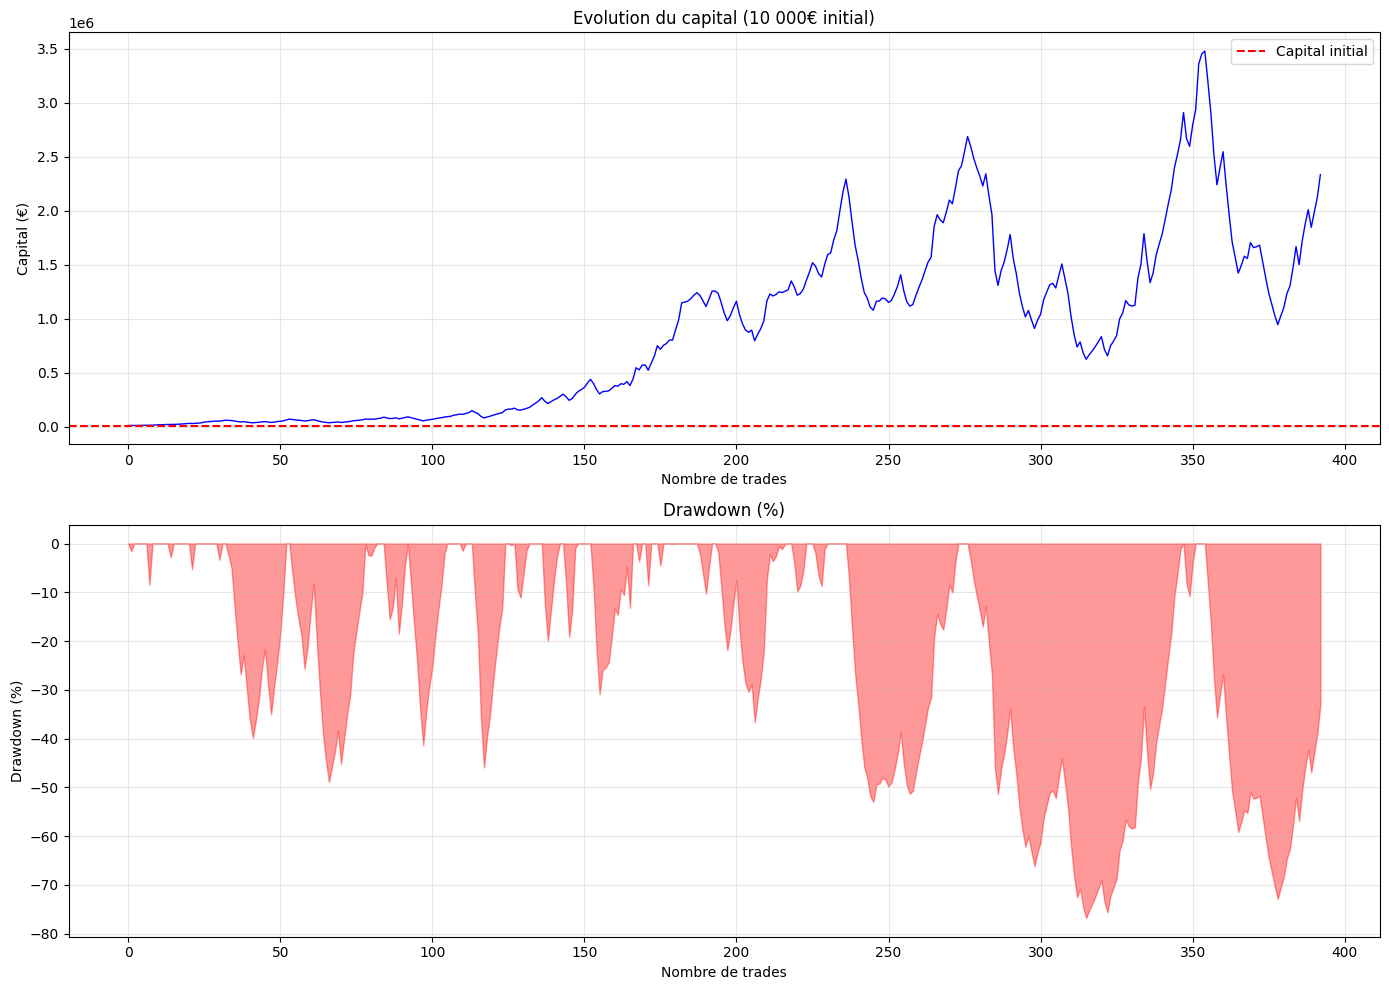

In [59]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 : Evolution du capital
ax1.plot(range(len(historique_capital)), historique_capital, color="blue", linewidth=1)
ax1.set_title("Evolution du capital (10 000€ initial)")
ax1.set_xlabel("Nombre de trades")
ax1.set_ylabel("Capital (€)")
ax1.grid(True, alpha=0.3)
ax1.axhline(y=10000, color="red", linestyle="--", label="Capital initial")
ax1.legend()

# Graphique 2 : Drawdown
ax2.fill_between(range(len(drawdown)), drawdown, 0, color="red", alpha=0.4)
ax2.set_title("Drawdown (%)")
ax2.set_xlabel("Nombre de trades")
ax2.set_ylabel("Drawdown (%)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()